In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df= pd.read_csv("smartcart_customers.csv")
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.shape


(2240, 22)

In [4]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [5]:
df["Age"]= 2026-df["Year_Birth"]

In [6]:
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference= df["Dt_Customer"].max()
df["Customer_ten"]=( reference- df["Dt_Customer"]).dt.days

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
Age                    0
Customer_ten           0
dtype: int64

In [8]:
df["Tot_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]
df["Tot_child"]=df["Teenhome"]+df["Kidhome"]

In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_ten,Tot_spending,Tot_child
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [10]:
df["Education"]=df["Education"].replace({
    "Basic": "Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate","PhD":"Postgraduate"
    
})

In [11]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [12]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [13]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [14]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]

spending=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
totcols= cols+ spending

df_cleaned= df.drop(columns=totcols)

In [15]:
df_cleaned.shape


(2240, 15)

In [16]:
df.shape

(2240, 27)

In [17]:
print("Data size with outliers:", len(df_cleaned))

df_cleaned= df_cleaned[ (df_cleaned["Age"]<90) ]
df_cleaned= df_cleaned[(df_cleaned[ "Income"]<600_000) ]

print("Data size without outliers:", len(df_cleaned))


Data size with outliers: 2240
Data size without outliers: 2236


In [18]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder()
cat_cols= ["Education","Living_With"]

enc_cols= ohe.fit_transform(df_cleaned[cat_cols])

In [19]:
enc_df= pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index )

In [20]:
df_encoded= pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [21]:
df_encoded.shape

(2236, 18)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X=df_encoded

X_scaled= scaler.fit_transform(X)


In [23]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)

X_pca=pca.fit_transform(X_scaled)



In [24]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D')

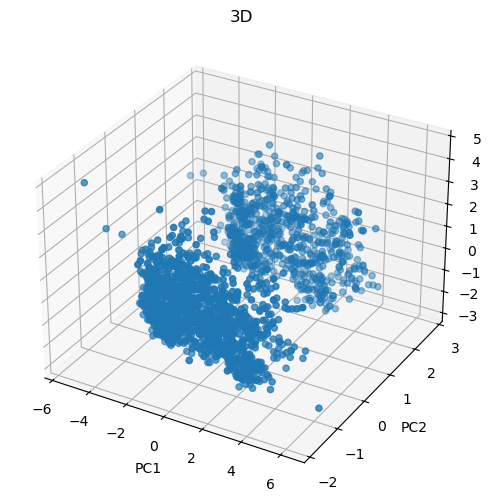

In [25]:
fig= plt.figure(figsize=(8,6))
ax= fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D")

In [26]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range (1,11):
    kmean=KMeans(n_clusters=k, random_state=42)
    kmean.fit_predict(X_pca)
    wcss.append(kmean.inertia_)


In [27]:
knee= KneeLocator(range(1,11),wcss,curve="convex", direction="decreasing")
optimal_K= knee.elbow

In [28]:
print("Best k value:",optimal_K)

Best k value: 4


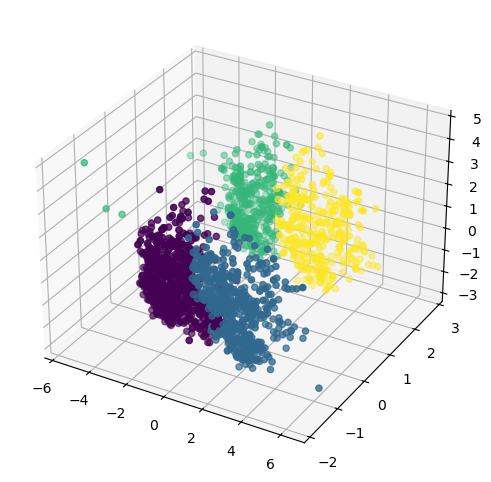

In [29]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

In [33]:
X["clusters"]=labels_agg

In [34]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_ten,Tot_spending,Tot_child,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Tot_spending', ylabel='Income'>

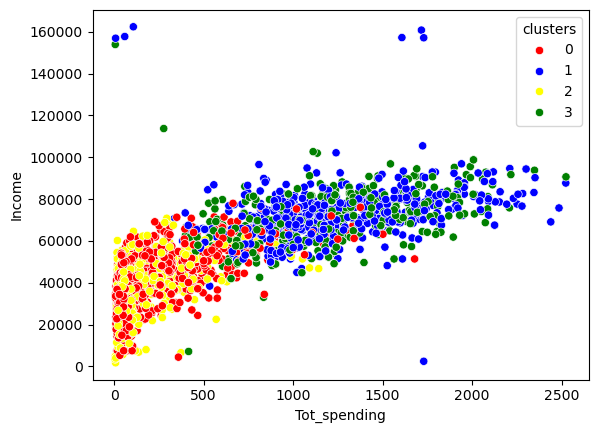

In [37]:
pal=["red","blue","yellow","green"]
sns.scatterplot(y=X["Income"], x=X["Tot_spending"], hue= X["clusters"], palette=pal)

In [39]:
cluster_summary= X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_ten  Tot_spending  Tot_child  \
cl